<a href="https://colab.research.google.com/github/vyunus/Limpieza-de-datos-bencinera-2022/blob/main/Bencinera_marzo_2022.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df=pd.read_csv('transacciones_bencinera.csv')
df

,unique_id_transa,id_transaccion,id_vehiculo,id_usuario,id_equipo,veh_site_id,pump_site_id,tank_site_id,user_site_id,producto,...,temp_final,volumen_comp_15_inicial,volumen_comp_15_final,cantidad_comp_15,codigo_producto,geo_latitud,geo_longitud,id_empresa,id_industria,industria
0,159220129006228,6228,59716,5888,159,000000,6,1,0000,1.0,...,28.6,7261.32,7252.17,0.84,V-Power Nafta,NaN,NaN,45,6.0,Service Station
1,891220114006546,6546,122939,29910,891,000415,6,7,0000,1.0,...,27.8,6683.23,6585.63,49.65,NaN,NaN,NaN,1116,1.0,Transportation
2,520220106007982,7982,995197,7451,520,002839,3,3,0006,2.0,...,25.2,13534.30,13097.20,443.64,405200,NaN,NaN,115,1.0,Transportation
3,320220223005186,5186,50546,3856,320,000267,1,1,0004,0.0,...,NaN,NaN,NaN,239.64,Diesel 500 PPM,NaN,NaN,182,7.0,Construction
4,102220316007888,7888,149394,462,102,017068,1,1,0001,0.0,...,NaN,NaN,NaN,18.46,Product 1,NaN,NaN,31,1.0,Transportation
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
380060,1056220328001224,1224,1001898,47318,1056,000021,2,1,0000,1.0,...,NaN,8716.16,NaN,40.01,NaN,NaN,NaN,1231,NaN,NaN
380061,400220115001677,1677,54160,8412,400,000007,1,1,0000,0.0,...,30.1,28037.40,27918.90,106.41,Formula Diesel,NaN,NaN,230,1.0,Transportation
380062,481220202005234,5234,57609,5463,481,000124,2,2,0003,0.0,...,24.7,26916.80,26773.30,147.22,Diesel,NaN,NaN,227,1.0,Transportation
380063,477220310008664,8664,59719,5905,477,000000,2,2,0000,1.0,...,NaN,7174.54,NaN,27.18,Super,NaN,NaN,100,6.0,Service Station


In [132]:
#eliminamos las columnas no utilizadas
df = df.drop(columns=['id_transaccion','id_equipo','pump_site_id','tank_site_id','user_site_id',
                      'volumen_inicial','volumen_final','temp_inicial','temp_final','volumen_comp_15_inicial',
                      'volumen_comp_15_final','codigo_producto','geo_latitud','geo_longitud','id_industria'])

In [ ]:
'Columnas eliminadas'
#id_transaccion: se elimina ya que existe un identificador unico unique_id_transa
#id_equipo: este identificador no es relevante para el trabajo
#pump_site_id: se elimina, ya que la información también la tenemos en id_bomba
#tank_site_id: se elimina, porque no es necesario para nuestro analisis
#user_site_id: tiene demasiados datos faltantes y es innecesario
#volumen_inicial: es el volumen de combustible con el que esta cargado al llegar (es innecesario)
#volumen_final: volumen de combustible al finalizar la carga
#temp_inicial: es la temperatura de combustible al llegar (es innecesario)
#temp_final: temperatura de combustible al finalizar la carga
#volumen_comp_15_inicial: no es relevante para el analisis
#volumen_comp_15_final: no es relevante para el analisis
#codigo_producto: ya existe la columna nombre_prod
#geo_latitud: ubicacion precisa (no lo usaremos)
#geo_longitud: ubicacion precisa (no lo usaremos)
#id_industria: ya sabemos a que industria pertenece en la columna industria

In [133]:
#revisamos que se hayan eliminado correctamente
df.columns

Index(['unique_id_transa', 'id_vehiculo', 'id_usuario', 'veh_site_id',
       'producto', 'id_bomba', 'id_tanque', 'departamento', 'cantidad',
       'codigo_error', 'timestamp', 'timestamp_stop', 'nombre_prod',
       'veh_efficiency', 'cantidad_comp_15', 'id_empresa', 'industria'],
      dtype='object')

In [134]:
#check valores duplicados
dup_total = df.duplicated().sum()

In [135]:

print("\nRegistros detectados como duplicados:")
print(df[df.duplicated(keep=False)])


Registros detectados como duplicados:
        unique_id_transa  id_vehiculo  id_usuario veh_site_id  producto  \
1364     159220323000068        59716        5888      000000       0.0   
3347     477220307007364        59719        5905      000000       2.0   
6039     159220326002182        59716        5888      000000       0.0   
11770    139220219005601        39920        1045      000005       1.0   
12947    671220214009844      1000961       55072      EL0219       0.0   
...                  ...          ...         ...         ...       ...   
373288   159220326002182        59716        5888      000000       0.0   
375275   453220107008152        59967       45026      000437       0.0   
375537   848220112006663       131550       25019      BW0024       0.0   
376041   891220218008217       122860       29910      000262       1.0   
377543   891220218008217       122860       29910      000262       1.0   

        id_bomba  id_tanque departamento  cantidad codigo_er

In [136]:
# Limpiamos los datos duplicados
df = df.drop_duplicates().copy()
print("\nLimpieza realizada. Nuevo total de filas:", len(df))


Limpieza realizada. Nuevo total de filas: 380000


In [137]:
# Identificamos cuántos datos nulos tenemos en las columnas
nulos_por_columna = df.isnull().sum()
print("Conteo de datos faltantes por columna:")
print(nulos_por_columna)

Conteo de datos faltantes por columna:
unique_id_transa        0
id_vehiculo             0
id_usuario              0
veh_site_id             5
producto             3478
id_bomba                0
id_tanque               0
departamento            0
cantidad             6000
codigo_error         8509
timestamp           13483
timestamp_stop       4859
nombre_prod         12610
veh_efficiency       8000
cantidad_comp_15    14842
id_empresa              0
industria           33879
dtype: int64


In [138]:
print(round(df['producto'].describe()),2)
#Revisada con describe() para ver cuartiles, media, maximos y minimos

count    376522.0
mean          0.0
std          58.0
min       -3851.0
25%           0.0
50%           0.0
75%           1.0
max        3460.0
Name: producto, dtype: float64 2


In [145]:
df['producto'] = pd.to_numeric(df['producto'], errors='coerce')
#Transformacion a numericos, sino se marca como nulo

In [147]:
df['producto'] = df['producto'].fillna(1) #de nulo a 1 para tener mejor manejo de los datos

In [143]:
import pandas as pd

print('---LIMPIEZA---')

# trabajamos una lista especifica con valores cerrados de el 0 al 4
df['producto'] = pd.to_numeric(df['producto'], errors='coerce')
df['producto'] = df['producto'].where(df['producto'].isin([0, 1, 2, 3, 4]))#Check de si se cumple dicha condicion (0 a 4)

# rellenamos los datos nulos con la moda
moda_producto = df['producto'].mode()
df['producto'] = df['producto'].fillna(moda_producto) #Se trabaja con la moda en los nulos
print("Columna producto a numero entero:")
print(df['producto'].value_counts())

---LIMPIEZA---
Columna producto a numero entero:
producto
0.0    267307
1.0     87479
2.0     16366
3.0      6001
4.0       900
Name: count, dtype: int64


In [148]:
print("\n--- REPORTE DE NULOS DE PRODUCTO ---")
print(df['producto'].isnull().sum()) #Check matutino de nulos


--- REPORTE DE NULOS DE PRODUCTO ---
0


In [149]:
#Calculamos la mediana de la columna cantidad al pertenecer al 50% de los datos
mediana_cantidad = df['cantidad'].median()

# Rellenamos los valores nulos con la mediana
df['cantidad'] = df['cantidad'].fillna(mediana_cantidad)

# tambien se limpia la cant_comp_15 y sus valores nulos se sustituyen por la mediana
df['cantidad_comp_15'] = df['cantidad_comp_15'].fillna(df['cantidad_comp_15'].median())

print(f"{mediana_cantidad}")

60.98


In [150]:
nulos_cantidad = df['cantidad'].isnull().sum()
print(f"Nulos encontrados en cantidad: {nulos_cantidad}")#Check de nulos en cantidad

Nulos encontrados en cantidad: 0


In [169]:
import numpy as np
#Se utiliza el rango intercuartilico de manera que podamos determinar tanto los valores extremos como los minimos


# calculamos el rango normal (IQR: sacando Q1 y Q3 para definir el Límite Superior)
Q1_cant = df['cantidad'].quantile(0.25)
Q3_cant = df['cantidad'].quantile(0.75)
limite_sup_cant = Q3_cant + 1.5 * (Q3_cant - Q1_cant)

Q1_comp = df['cantidad_comp_15'].quantile(0.25)
Q3_comp = df['cantidad_comp_15'].quantile(0.75)
limite_sup_comp = Q3_comp + 1.5 * (Q3_comp - Q1_comp)

# filtramos los numeros grandes usando np.where como un condicional rápido
#se consulta una fila y en caso de superar el limite maximo, lo remplazamos por la mediana. En caso de ser un valor normal se queda igual
df['cantidad'] = np.where(df['cantidad'] > limite_sup_cant, df['cantidad'].median(), df['cantidad'])
df['cantidad_comp_15'] = np.where(df['cantidad_comp_15'] > limite_sup_comp, df['cantidad_comp_15'].median(), df['cantidad_comp_15'])


# Estos numeros atipicos se reemplazan al igual que el anterior, por la mediana
df['cantidad'] = np.where(df['cantidad'] <= 0, df['cantidad'].median(), df['cantidad'])
df['cantidad_comp_15'] = np.where(df['cantidad_comp_15'] <= 0, df['cantidad_comp_15'].median(), df['cantidad_comp_15'])


print(df[['cantidad', 'cantidad_comp_15']].describe().round(2))

        cantidad  cantidad_comp_15
count  380000.00         380000.00
mean       74.57             72.70
std        66.03             63.18
min         0.01              0.01
25%        32.34             33.38
50%        60.98             60.38
75%        87.69             82.55
max       315.35            304.09


In [151]:
# Identificamos nuevamente cuantos   datos nulos tenemos en las columnas
nulos_por_columna = df.isnull().sum()
print("Conteo de datos faltantes por columna:")
print(nulos_por_columna)

Conteo de datos faltantes por columna:
unique_id_transa        0
id_vehiculo             0
id_usuario              0
veh_site_id             5
producto                0
id_bomba                0
id_tanque               0
departamento            0
cantidad                0
codigo_error         8509
timestamp           13483
timestamp_stop       4859
nombre_prod         12610
veh_efficiency       8000
cantidad_comp_15        0
id_empresa              0
industria           33879
dtype: int64


In [152]:
df['codigo_error'].value_counts()

,count
codigo_error,
C1,182810
ES,65633
H1,32119
C4,27590
BF,18898
...,...
H{2,1
|UL,1
~H2,1


In [153]:
df['codigo_error'] = df['codigo_error'].str.replace(r'[^a-zA-Z0-9 ]', '', regex=True)#Formateo de los caracteres basura
print(df['codigo_error'].head(10))

0    ES
1    C1
2    C1
3    C1
4    C1
5    ES
6    C1
7    C1
8    ES
9    H1
Name: codigo_error, dtype: object


In [154]:
# Reemplazo de nulos siguiento el formato del codigo error
df['codigo_error'].fillna('NA')

,codigo_error
0,ES
1,C1
2,C1
3,C1
4,C1
...,...
380060,C1
380061,NA
380062,BF
380063,ES


In [155]:
df['codigo_error'] = df['codigo_error'].fillna('NA')
print(df.isnull().sum())

unique_id_transa        0
id_vehiculo             0
id_usuario              0
veh_site_id             5
producto                0
id_bomba                0
id_tanque               0
departamento            0
cantidad                0
codigo_error            0
timestamp           13483
timestamp_stop       4859
nombre_prod         12610
veh_efficiency       8000
cantidad_comp_15        0
id_empresa              0
industria           33879
dtype: int64


In [156]:
#limpieza caracter basura industria
df['industria'] = df['industria'].str.replace(r'[^a-zA-Z0-9 ]', '', regex=True)#Formateo de los caracteres basura
print(df['industria'].head(10))

0    Service Station
1     Transportation
2     Transportation
3       Construction
4     Transportation
5    Service Station
6     Transportation
7     Transportation
8    Service Station
9    Service Station
Name: industria, dtype: object


In [157]:
df['industria'].unique().tolist() #Se revisa que esten todas las industrias validas

['Service Station',
 'Transportation',
 'Construction',
 'OilGas',
 'Agriculture',
 nan,
 'Distributor',
 'Mining',
 'Industry',
 'Public',
 'Telcos']

In [158]:
# Rellenamos los nulos de industria creamos una nueva categoria llamada desconocido
df['industria'] = df['industria'].fillna('Desconocido')

# Verificamos si queda algun nulo en industria
print(f"Nulos restantes en industria: {df['industria'].isnull().sum()}")


print(df['industria'].value_counts().head())

Nulos restantes en industria: 0
industria
Transportation     133496
Service Station    114308
Desconocido         33879
Agriculture         28536
Construction        22962
Name: count, dtype: int64


In [161]:
import pandas as pd
import numpy as np
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df['timestamp_stop'] = pd.to_datetime(df['timestamp_stop'], errors='coerce')

In [163]:
 #restamoos las fechas para calcular el tiempo de carga
df['duracion_carga_seg'] = (df['timestamp_stop'] - df['timestamp']).dt.total_seconds()

In [164]:
#Lunes=0, Domingo=6
df['dia_de_semana'] = df['timestamp'].dt.dayofweek

In [165]:
# eliminamos estas columnas ya que extrajimos su info para crear las nuevas
df = df.drop(columns=['timestamp', 'timestamp_stop'])

In [166]:
#se rellenan las fechas vacias
df['duracion_carga_seg'] = df['duracion_carga_seg'].fillna(df['duracion_carga_seg'].median())
df['dia_de_semana'] = df['dia_de_semana'].fillna(df['dia_de_semana'].mode()[0])

In [167]:

print(df[['duracion_carga_seg', 'dia_de_semana']].head())

   duracion_carga_seg  dia_de_semana
0                87.0            0.0
1                68.0            4.0
2               562.0            3.0
3                87.0            0.0
4                 0.0            2.0


In [170]:
# Identificamos cuantos datos nulos tenemos en las columnas
nulos_por_columna = df.isnull().sum()
print("Conteo de datos faltantes por columna:")
print(nulos_por_columna)

Conteo de datos faltantes por columna:
unique_id_transa          0
id_vehiculo               0
id_usuario                0
veh_site_id               5
producto                  0
id_bomba                  0
id_tanque                 0
departamento              0
cantidad                  0
codigo_error              0
nombre_prod           12610
veh_efficiency         8000
cantidad_comp_15          0
id_empresa                0
industria                 0
duracion_carga_seg        0
dia_de_semana             0
dtype: int64


In [172]:
#al crear un "diccionario" o mapa de datos completos nos permite agrupar el codigo producto por nombre producto
mapa_productos = df.dropna(subset=['nombre_prod']).set_index('producto')['nombre_prod'].to_dict()

# se puede ver cual codigo producto pertenece al nombre producto
print("Mapa de productos descubierto:", mapa_productos)

Mapa de productos descubierto: {1.0: 'Super', 2.0: 'VP Diesel', 0.0: 'Diesel 500', 3.0: 'Formula Diesel', 4.0: 'UREA'}


In [173]:

# con el mapa creado se rellenan los nombre_prod vacios basandose en su codigo
df['nombre_prod'] = df['nombre_prod'].fillna(df['producto'].map(mapa_productos))

# Verificamos cuantos nulos logramos salvar
nulos_restantes = df['nombre_prod'].isnull().sum()
print(f"\nNulos restantes en nombre_prod después del rescate inteligente: {nulos_restantes}")


Nulos restantes en nombre_prod después del rescate inteligente: 0


In [175]:
# auqellos que no fueron encontrados, los dejaremos con el nombre producto sin registro
df['nombre_prod'] = df['nombre_prod'].fillna('Producto Sin Registro')

In [176]:
filas_parchadas = df[df['nombre_prod'] == 'Producto Sin Registro']

print(f"Hay {len(filas_parchadas)} filas con este parche.")


print(filas_parchadas[['producto', 'nombre_prod', 'cantidad']].head())

Hay 0 filas con este parche.
Empty DataFrame
Columns: [producto, nombre_prod, cantidad]
Index: []


In [177]:
#Originalmente se iba a trabajar con la columna pero al tener poca riqueza en datos se descarta
df = df.drop(columns=['veh_efficiency'])

In [178]:
nulos_por_columna = df.isnull().sum()
print("Conteo de datos faltantes por columna:")
print(nulos_por_columna)

Conteo de datos faltantes por columna:
unique_id_transa      0
id_vehiculo           0
id_usuario            0
veh_site_id           5
producto              0
id_bomba              0
id_tanque             0
departamento          0
cantidad              0
codigo_error          0
nombre_prod           0
cantidad_comp_15      0
id_empresa            0
industria             0
duracion_carga_seg    0
dia_de_semana         0
dtype: int64


In [179]:
# 1. Las Importaciones (Nuevas Herramientas de Control)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Definimos cuáles son nuestras columnas numéricas y categóricas
columnas_numericas = ['cantidad', 'cantidad_comp_15']
columnas_categoricas = ['industria', 'nombre_prod', 'producto', 'codigo_error']

# 2. Definición del Procesador (El "Plan Maestro")
preprocesador = ColumnTransformer(transformers=[
    ('num', StandardScaler(), columnas_numericas), # Estándar: Media 0, Desv 1
    ('cat', OneHotEncoder(handle_unknown='ignore'), columnas_categoricas) # Crea columnas binarias
])

# 3.(Pipeline)
pipeline_final = Pipeline(steps=[('prep', preprocesador)])

# 4. Ejecución Mágica: fit_transform
# Resultado: Una matriz lista para la Inteligencia Artificial
datos_listos = pipeline_final.fit_transform(df)


print("Tamaño de la matriz final transformada (filas y columnas)")
print(datos_listos.shape)

Tamaño de la matriz final transformada (filas y columnas)
(380000, 4218)


In [181]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

print("--- 2. TRANSFORMACIÓN MANUAL  ---")

# Creamos una copia para no alterar nuestro dataset limpio original
df_manual = df.copy()

# A. Label Encoding (Palabras a numeros secuenciales)
# Convertimos las palabras de 'industria' en números mineria=0, Transporte=1
le = LabelEncoder()
df_manual['industria_ID'] = le.fit_transform(df_manual['industria'].astype(str))

# Min- Max Scaling (Escalar la cantidad de litros entre 0 y 1)
# La carga mas pequeña de la historia sera 0, y la más grande sera 1.
mm_scaler = MinMaxScaler()
df_manual['cantidad_Norm'] = mm_scaler.fit_transform(df_manual[['cantidad']])

# Comprobación Visual
print("\nComparación: Original vs Transformado")
# Mostramos una muestra de como se ven las columnas viejas junto a las nuevas
print(df_manual[['industria', 'industria_ID', 'cantidad', 'cantidad_Norm']].head(10))
print("-" * 50)

--- 2. TRANSFORMACIÓN MANUAL  ---

Comparación: Original vs Transformado
         industria  industria_ID  cantidad  cantidad_Norm
0  Service Station             8      0.86       0.002696
1   Transportation            10     50.29       0.159447
2   Transportation            10     60.98       0.193347
3     Construction             1    239.64       0.759910
4   Transportation            10     18.46       0.058508
5  Service Station             8      9.01       0.028541
6   Transportation            10     92.75       0.294095
7   Transportation            10    170.61       0.541003
8  Service Station             8     30.00       0.095104
9  Service Station             8     66.46       0.210725
--------------------------------------------------


In [180]:
df_manual[['industria', 'industria_ID', 'cantidad', 'cantidad_Norm']].head(10)

,industria,industria_ID,cantidad,cantidad_Norm
0,Service Station,8,0.86,0.002696
1,Transportation,10,50.29,0.159447
2,Transportation,10,60.98,0.193347
3,Construction,1,239.64,0.759910
4,Transportation,10,18.46,0.058508
5,Service Station,8,9.01,0.028541
6,Transportation,10,92.75,0.294095
7,Transportation,10,170.61,0.541003
8,Service Station,8,30.00,0.095104
9,Service Station,8,66.46,0.210725


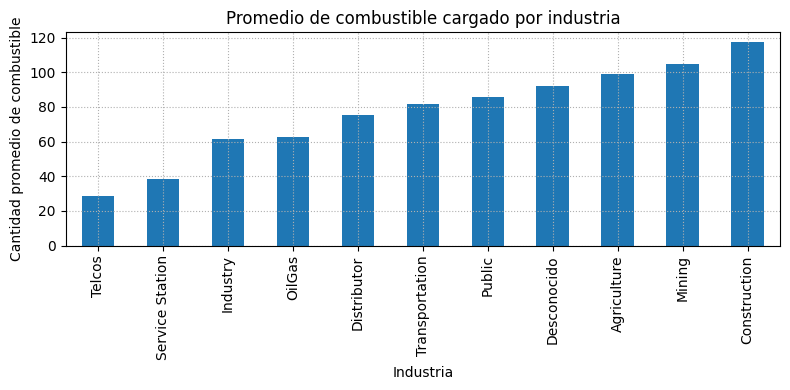

In [182]:
fig, ax = plt.subplots(figsize=(8,4))

df.groupby('industria')['cantidad_comp_15'].mean().sort_values().plot(kind='bar', ax=ax)

ax.set_ylabel("Cantidad promedio de combustible")
ax.set_xlabel("Industria")
ax.set_title("Promedio de combustible cargado por industria")

ax.grid(linestyle=":")

plt.tight_layout()
plt.show()